# 🔍 Cantilever Bridge SHM — Testing & Prediction
Run this **after** `01_train_model.ipynb`.  
Needs: `shm_model.pkl`, `scaler.pkl`, `label_encoder.pkl`, `features.pkl`

In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize

print('Imports OK.')

Imports OK.


In [2]:
# ── 1. Load saved artefacts ───────────────────────────────────────────────────
model    = joblib.load('shm_model.pkl')
scaler   = joblib.load('scaler.pkl')
le       = joblib.load('label_encoder.pkl')
FEATURES = joblib.load('features.pkl')

print('Loaded model:', type(model).__name__)
print('Features:', FEATURES)
print('Classes:', list(le.classes_))

Loaded model: XGBClassifier
Features: ['RMS', 'Std', 'Kurtosis', 'Skewness', 'Peak', 'Crest_Factor', 'Shape_Factor', 'Energy', 'Natural_Freq', 'Spec_Centroid', 'Band_Low', 'Band_Natural', 'Band_High', 'Spec_Entropy', 'AR1', 'AR2', 'AR_Resid_Std', 'Corr_XZ', 'Corr_YZ']
Classes: [np.str_('Healthy'), np.str_('Light Damage'), np.str_('Moderate Damage'), np.str_('Severe Damage')]


In [3]:
# ── 2. Reload dataset and recreate the SAME test split ───────────────────────
# Must use identical random_state=42 to get the exact same test set
CSV_PATH = 'cantilever_features.csv'

df = pd.read_csv(CSV_PATH).drop(columns=['sample_id', 'session', 'damage_level']).dropna()

label_order = ['Healthy', 'Light Damage', 'Moderate Damage', 'Severe Damage']
le_fixed = LabelEncoder()
le_fixed.fit(label_order)

y = le_fixed.transform(df['damage_label'])
X = df.drop(columns=['damage_label'])[FEATURES]

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_test_s = scaler.transform(X_test)

print(f'Test set: {X_test_s.shape[0]} samples')

Test set: 288 samples


In [4]:
# ── 3. Full test-set evaluation ───────────────────────────────────────────────
y_pred     = model.predict(X_test_s)
y_prob     = model.predict_proba(X_test_s)
test_acc   = (y_pred == y_test).mean()

print(f'Test Accuracy: {test_acc:.4f} ({test_acc:.2%})')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_fixed.classes_))

Test Accuracy: 0.3854 (38.54%)

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.40      0.33      0.36        72
   Light Damage       0.39      0.43      0.41        72
Moderate Damage       0.32      0.29      0.31        72
  Severe Damage       0.42      0.49      0.45        72

       accuracy                           0.39       288
      macro avg       0.38      0.39      0.38       288
   weighted avg       0.38      0.39      0.38       288



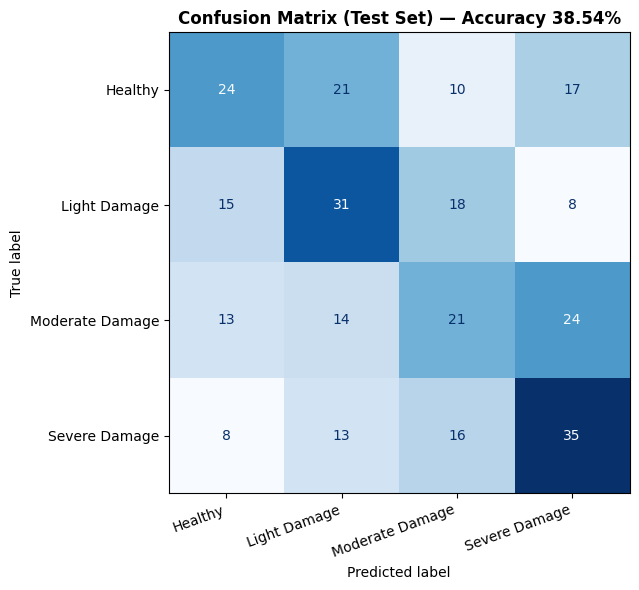

In [5]:
# ── 4. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=le_fixed.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix (Test Set) — Accuracy {test_acc:.2%}',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

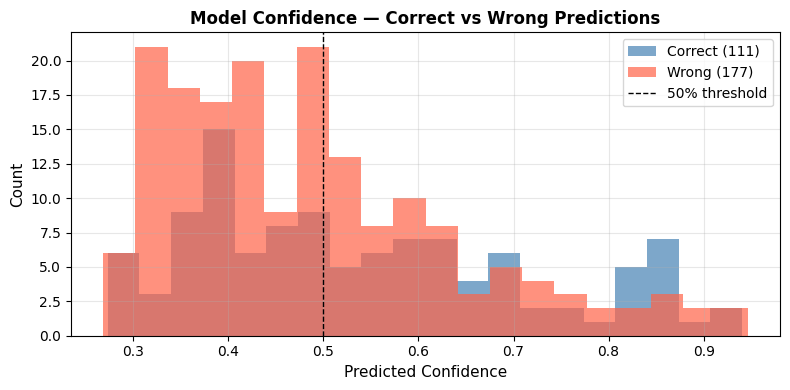

In [6]:
# ── 5. Per-class confidence distribution ─────────────────────────────────────
# Shows how confident the model is for correct vs wrong predictions
correct_conf  = y_prob[np.arange(len(y_pred)), y_pred][y_pred == y_test]
wrong_conf    = y_prob[np.arange(len(y_pred)), y_pred][y_pred != y_test]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(correct_conf, bins=20, alpha=0.7, label=f'Correct ({len(correct_conf)})',
        color='steelblue')
if len(wrong_conf):
    ax.hist(wrong_conf, bins=20, alpha=0.7, label=f'Wrong ({len(wrong_conf)})',
            color='tomato')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('Predicted Confidence', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Model Confidence — Correct vs Wrong Predictions', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── 6. ROC-AUC (one-vs-rest) ─────────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
auc_scores = {}
for i, cls in enumerate(le_fixed.classes_):
    auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    auc_scores[cls] = auc
    print(f'  AUC ({cls}): {auc:.4f}')

macro_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
print(f'\nMacro-average AUC: {macro_auc:.4f}')

  AUC (Healthy): 0.6267
  AUC (Light Damage): 0.6701
  AUC (Moderate Damage): 0.5646
  AUC (Severe Damage): 0.7026

Macro-average AUC: 0.6410


In [8]:
# ── 7. Misclassification inspector ───────────────────────────────────────────
# Shows which samples were wrong and what they were confused with
mistakes = X_test.copy()
mistakes['true_label']      = le_fixed.inverse_transform(y_test)
mistakes['predicted_label'] = le_fixed.inverse_transform(y_pred)
mistakes['confidence']      = y_prob[np.arange(len(y_pred)), y_pred]
mistakes = mistakes[mistakes['true_label'] != mistakes['predicted_label']]

print(f'Total misclassified: {len(mistakes)} / {len(y_test)}')
if len(mistakes):
    print()
    print(mistakes[['true_label', 'predicted_label', 'confidence']].to_string())

Total misclassified: 177 / 288

           true_label  predicted_label  confidence
160           Healthy     Light Damage    0.342749
418      Light Damage    Severe Damage    0.448921
1058  Moderate Damage          Healthy    0.633947
698      Light Damage    Severe Damage    0.332466
315           Healthy     Light Damage    0.330875
1188    Severe Damage          Healthy    0.490561
978   Moderate Damage    Severe Damage    0.721722
953   Moderate Damage    Severe Damage    0.858753
1021  Moderate Damage    Severe Damage    0.860526
217           Healthy    Severe Damage    0.700831
1227    Severe Damage  Moderate Damage    0.307022
538      Light Damage          Healthy    0.582249
484      Light Damage  Moderate Damage    0.306411
1322    Severe Damage  Moderate Damage    0.534156
711      Light Damage          Healthy    0.564041
1             Healthy  Moderate Damage    0.359568
1206    Severe Damage  Moderate Damage    0.518126
269           Healthy     Light Damage    0.673982

In [9]:
# ── 8. Predict single new samples ─────────────────────────────────────────────
# These are SIGNAL FEATURES ONLY — no damage_level, no session
# Replace the values below with your actual measured features

def predict_sample(features_dict):
    """Predict damage class from a dict of signal features."""
    row = pd.DataFrame([features_dict])[FEATURES]
    row_s = scaler.transform(row)
    pred  = model.predict(row_s)[0]
    probs = model.predict_proba(row_s)[0]
    label = le_fixed.inverse_transform([pred])[0]
    print(f'Prediction  : {label}')
    print(f'Confidence  : {probs[pred]:.2%}')
    print('Class probs :')
    for cls, p in zip(le_fixed.classes_, probs):
        bar = '#' * int(p * 30)
        print(f'  {cls:<18} {p:.3f}  |{bar}')
    print()
    return label, probs


# ── Test with real rows pulled from the dataset ──────────────────────────────
raw_df = pd.read_csv(CSV_PATH).drop(columns=['sample_id', 'session', 'damage_level']).dropna()

for true_label in ['Healthy', 'Light Damage', 'Moderate Damage', 'Severe Damage']:
    row = raw_df[raw_df['damage_label'] == true_label][FEATURES].iloc[0].to_dict()
    print(f'--- True label: {true_label} ---')
    predict_sample(row)

--- True label: Healthy ---
Prediction  : Healthy
Confidence  : 63.96%
Class probs :
  Healthy            0.640  |###################
  Light Damage       0.135  |####
  Moderate Damage    0.112  |###
  Severe Damage      0.113  |###

--- True label: Light Damage ---
Prediction  : Light Damage
Confidence  : 50.02%
Class probs :
  Healthy            0.282  |########
  Light Damage       0.500  |###############
  Moderate Damage    0.143  |####
  Severe Damage      0.074  |##

--- True label: Moderate Damage ---
Prediction  : Light Damage
Confidence  : 47.68%
Class probs :
  Healthy            0.314  |#########
  Light Damage       0.477  |##############
  Moderate Damage    0.093  |##
  Severe Damage      0.116  |###

--- True label: Severe Damage ---
Prediction  : Healthy
Confidence  : 31.92%
Class probs :
  Healthy            0.319  |#########
  Light Damage       0.097  |##
  Moderate Damage    0.307  |#########
  Severe Damage      0.276  |########



In [10]:
# ── 9. Batch predict from a new CSV ──────────────────────────────────────────
# If you have new unlabelled windows, load them here
# The CSV must contain the same 19 feature columns (no damage_level, no session)

NEW_CSV = None   # set to e.g. 'new_readings.csv' to enable

if NEW_CSV:
    new_df  = pd.read_csv(NEW_CSV)[FEATURES].dropna()
    new_s   = scaler.transform(new_df)
    preds   = model.predict(new_s)
    probs   = model.predict_proba(new_s)

    new_df['predicted_label']   = le_fixed.inverse_transform(preds)
    new_df['confidence']        = probs[np.arange(len(preds)), preds]

    print(new_df[['predicted_label', 'confidence']].head(20).to_string())
    new_df.to_csv('batch_predictions.csv', index=False)
    print('Saved: batch_predictions.csv')
else:
    print('Set NEW_CSV path to run batch prediction.')

Set NEW_CSV path to run batch prediction.


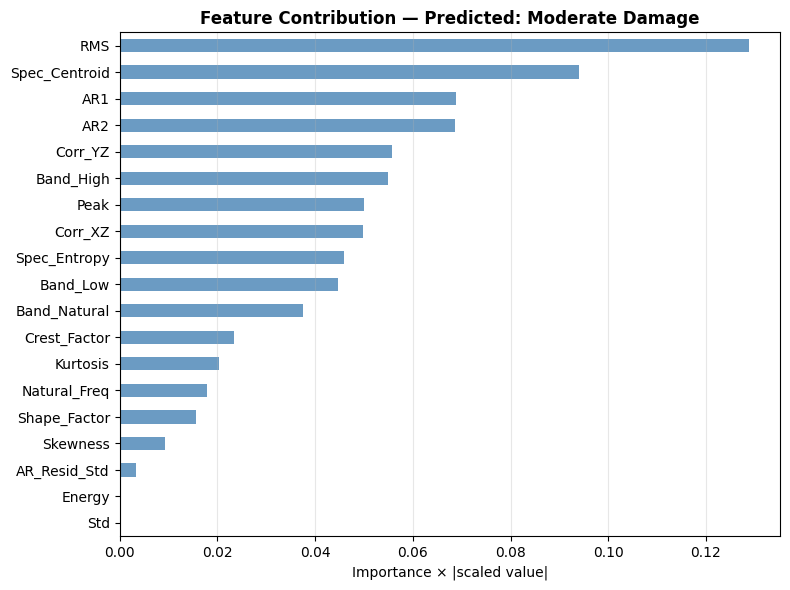

In [11]:
# ── 10. Feature contribution for one prediction (if RF/XGB) ──────────────────
# Approximation: importance × |feature value| to show what drove this decision

if hasattr(model, 'feature_importances_'):
    sample_row = X_test.iloc[0]
    sample_s   = scaler.transform(sample_row.values.reshape(1, -1))
    pred_class = le_fixed.inverse_transform(model.predict(sample_s))[0]

    contrib = pd.Series(
        model.feature_importances_ * np.abs(sample_s[0]),
        index=FEATURES
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    contrib.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title(f'Feature Contribution — Predicted: {pred_class}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance × |scaled value|')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('sample_contribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Feature contribution only available for tree-based models.')

In [12]:
# ── 11. Summary printout ──────────────────────────────────────────────────────
print('=' * 55)
print('  CANTILEVER SHM MODEL — EVALUATION SUMMARY')
print('=' * 55)
print(f'  Model        : {type(model).__name__}')
print(f'  Test samples : {len(y_test)}')
print(f'  Accuracy     : {test_acc:.4f} ({test_acc:.2%})')
print(f'  Macro AUC    : {macro_auc:.4f}')
print(f'  Misclassified: {len(mistakes)}')
print()
print('  Per-class AUC:')
for cls, auc in auc_scores.items():
    print(f'    {cls:<18} {auc:.4f}')
print('=' * 55)

  CANTILEVER SHM MODEL — EVALUATION SUMMARY
  Model        : XGBClassifier
  Test samples : 288
  Accuracy     : 0.3854 (38.54%)
  Macro AUC    : 0.6410
  Misclassified: 177

  Per-class AUC:
    Healthy            0.6267
    Light Damage       0.6701
    Moderate Damage    0.5646
    Severe Damage      0.7026
